# Baseline and first gbm model 

# Table of Contents
- [ 1 - Introduction](#1)
  - [ 1.1 RAG architecture overview](#1-1)
  - [ 1.2 Importing the necessary libraries](#1-2)
- [ 2 - Loading the training and test dataset](#2)
- [ 3 - Exploratory Data Analysis and Data Preparation](#3)
  - [ 3.1 Inspecting the target variable](#3-1)
  - [ 3.2 checking duplicate rows](#3-2)
  - [ 3.3 Identifying numerical and categorical features](#3-3)
  - [ 3.5 Train / validation split](#3-5)
- [ 4 - Modeling Pipeline and Experiment Tracking](#3)
  - [ 4.1 Model Configuration ](#4-1)
  - [ 4.2 Model Training and MLflow Tracking ](#4-2)
---

<a id='1-1'></a>
### 1.1 Parameters

In [1]:
target = 'SeriousDlqin2yrs'
columns_to_drop = ['Unnamed: 0'] 

<a id='1-2'></a>
### 1.2 Importing the necessary libraries

In [3]:
# =========================
# Standard library
# =========================
import os
import sys
from pathlib import Path


# =========================
# Data manipulation
# =========================
import numpy as np
import pandas as pd


# =========================
# Configuration / serialization
# =========================
import yaml


# =========================
# Machine learning - preprocessing
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder, FunctionTransformer)


# =========================
# Machine learning - modeling
# =========================
from sklearn.tree import DecisionTreeClassifier


# =========================
# Machine learning - evaluation
# =========================
from sklearn.metrics import roc_auc_score


# =========================
# Machine learning - data splitting
# =========================
from sklearn.model_selection import train_test_split


# =========================
# Experiment tracking
# =========================
import mlflow
from mlflow.models.signature import infer_signature
import mlflow.sklearn


# =========================
# Local project path setup
# =========================
sys.path.extend([str(Path.cwd().parent)])


# =========================
# Local project modules
# =========================
import data
from utils import (
    lift_table,
    plot_lift,
    plot_roc_mpl,
    plot_roc_plotly,
    threshold_table,
)

<a id='2'></a>
## 2 - Loading the training and test dataset

In [4]:
train_data = pd.read_csv(filepath_or_buffer=os.path.join(os.path.dirname(data.__file__), "cs-training.csv"))

In [5]:
train_data

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [6]:
test_data = pd.read_csv(filepath_or_buffer=os.path.join(os.path.dirname(data.__file__), "cs-test.csv"))

In [7]:
test_data

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
101498,101499,NaN,0.282653,24,0,0.068522,1400.0,5,0,0,0,0.0
101499,101500,NaN,0.922156,36,3,0.934217,7615.0,8,0,2,0,4.0
101500,101501,NaN,0.081596,70,0,836.000000,NaN,3,0,0,0,NaN
101501,101502,NaN,0.335457,56,0,3568.000000,NaN,8,0,2,1,3.0


# 3 - Exploratory Data Analysis and Data Preparation

## 3.1 Inspecting the target variable

In [8]:
(train_data[target].value_counts(normalize=True)*100).round(2)

SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

In [9]:
train_data

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


## 3.2 checking duplicate rows

In [10]:
n_duplicates = train_data.drop(columns=["Unnamed: 0"]).duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 609


In [11]:
# train_data = train_data.drop_duplicates().reset_index(drop=True)

In [12]:
# train_data

## 3.3 Identifying numerical and categorical features

In [13]:
numerical_features   = [c for c in train_data.select_dtypes(include="number").columns if c not in [target] + columns_to_drop]
categorical_features = [c for c in train_data.select_dtypes(exclude="number").columns if c not in [target] + columns_to_drop]

print(f"Numerical   ({len(numerical_features)}):", numerical_features)
print(f"Categorical ({len(categorical_features)}):", categorical_features)

Numerical   (10): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Categorical (0): []


## 3.4 Missing values per column

In [14]:
missing_summary = pd.DataFrame({
    "missing_count":      train_data.isna().sum(),
    "missing_percentage": train_data.isna().mean() * 100,
})


missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
    .round({"missing_percentage": 2})
)

missing_summary

,missing_count,missing_percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


## 3.5 Train / validation split

In [15]:
X = train_data.drop(columns=target)
y = train_data[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Positive class ratio - train:      {y_train.mean().round(4)}")
print(f"Positive class ratio - validation: {y_val.mean().round(4)}")

Training set shape:   (120000, 11)
Validation set shape: (30000, 11)
Positive class ratio - train:      0.0668
Positive class ratio - validation: 0.0668


In [16]:
X_train

,Unnamed: 0,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
57836,57837,0.114987,62,0,1841.000000,NaN,5,0,1,0,2.0
132895,132896,0.008705,73,0,0.498553,3800.0,6,0,1,0,0.0
27981,27982,0.214501,32,0,0.211999,3716.0,8,0,0,0,2.0
37852,37853,1.000000,60,0,118.000000,NaN,5,0,0,0,0.0
103813,103814,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
18048,18049,0.004136,41,0,0.472323,7695.0,9,0,2,0,0.0
3895,3896,0.000000,49,0,0.322344,8583.0,18,0,1,0,1.0
109980,109981,1.000000,80,0,35.000000,NaN,0,0,0,0,0.0
74354,74355,0.925187,63,0,0.389974,1535.0,2,1,0,0,0.0


# 4 Modeling Pipeline and Experiment Tracking

## 4.1 Model Configuration

In [17]:
with open(Path.cwd().parent / "config.yaml") as f:
    config = yaml.safe_load(f)

def build_classifier(cfg):
    mtype  = cfg["model"]["type"]
    params = cfg["params"][mtype]
    if mtype == "decision_tree":
        return DecisionTreeClassifier(**params)
    if mtype == "lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(**params)
    if mtype == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(**params)
    if mtype == "catboost":
        from catboost import CatBoostClassifier
        return CatBoostClassifier(verbose=0, **params)
    raise ValueError(f"Unknown model type: {mtype}")

classifier = build_classifier(config)
config

{'experiment_name': 'credit-scoring',
 'run_name': 'dtree_baseline',
 'description': 'Setting LR of lightgbm to 0.01',
 'model': {'type': 'lightgbm'},
 'params': {'decision_tree': {'criterion': 'gini',
   'splitter': 'best',
   'max_depth': 6,
   'min_samples_split': 20,
   'min_samples_leaf': 10,
   'min_weight_fraction_leaf': 0.0,
   'max_features': None,
   'max_leaf_nodes': 32,
   'min_impurity_decrease': 0.0,
   'class_weight': 'balanced',
   'ccp_alpha': 0.0,
   'random_state': 42},
  'lightgbm': {'n_estimators': 500,
   'learning_rate': 0.01,
   'num_leaves': 31,
   'max_depth': -1,
   'min_child_samples': 20,
   'subsample': 0.9,
   'colsample_bytree': 0.9,
   'reg_alpha': 0.0,
   'reg_lambda': 0.0,
   'class_weight': 'balanced',
   'random_state': 42,
   'n_jobs': -1},
  'xgboost': {'n_estimators': 500,
   'learning_rate': 0.01,
   'max_depth': 6,
   'min_child_weight': 1,
   'subsample': 0.9,
   'colsample_bytree': 0.9,
   'gamma': 0.0,
   'reg_alpha': 0.0,
   'reg_lambda': 1

## 4.2 Model Training and MLflow Tracking

In [18]:
def add_weighted_past_due(X):
    X = X.copy()
    X["WeightedPastDue"] = X["NumberOfTime30-59DaysPastDueNotWorse"] + 3 * X["NumberOfTimes90DaysLate"]
    return X


numerical_features = numerical_features + ["WeightedPastDue"]

pp = config["preprocessing"]["imputers"]

transformers = [(col, SimpleImputer(**spec), [col]) for col, spec in pp.items()]

if categorical_features:
    transformers.append(("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features))

remaining = [c for c in numerical_features if c not in pp]
if remaining:
    transformers.append(("keep", "passthrough", remaining))

preprocessor = ColumnTransformer(transformers)

pipeline = Pipeline(steps=[
    ("feature_engineering", FunctionTransformer(add_weighted_past_due)),
    ("preprocessor",        preprocessor),
    ("classifier",          classifier),
])


print("── Feature engineering ──")
print("  WeightedPastDue = NumberOfTime30-59DaysPastDueNotWorse + 3 * NumberOfTimes90DaysLate\n")

print("── Préprocesseur ──")
print(f"  Imputers      ({len(pp):>2}) : {list(pp.keys())}")
print(f"  Catégorielles ({len(categorical_features):>2}) : {categorical_features}")
print(f"  Passthrough   ({len(remaining):>2}) : {remaining}")
print(f"  Classifier    : {type(classifier).__name__}\n")

print("── Pipeline ──")
for i, (name, step) in enumerate(pipeline.steps):
    print(f"  [{i}] {name:20s} → {type(step).__name__}")

── Feature engineering ──
  WeightedPastDue = NumberOfTime30-59DaysPastDueNotWorse + 3 * NumberOfTimes90DaysLate

── Préprocesseur ──
  Imputers      ( 2) : ['MonthlyIncome', 'NumberOfDependents']
  Catégorielles ( 0) : []
  Passthrough   ( 9) : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'WeightedPastDue']
  Classifier    : LGBMClassifier

── Pipeline ──
  [0] feature_engineering  → FunctionTransformer
  [1] preprocessor         → ColumnTransformer
  [2] classifier           → LGBMClassifier


In [19]:
# =============================================================================
# MLFLOW TRACKING
# =============================================================================
# Logs params + train/val metrics for the current pipeline run.
# All behaviour is driven by `config` (loaded from config.yaml).
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Tracking backend + experiment
# -----------------------------------------------------------------------------
(Path.cwd().parent / "mlruns").mkdir(exist_ok=True)
mlflow.set_tracking_uri((Path.cwd().parent / "mlruns").as_uri())
mlflow.set_experiment(config["experiment_name"])


# -----------------------------------------------------------------------------
# 2. Open a run — everything below is attached to this run
# -----------------------------------------------------------------------------
with mlflow.start_run(run_name=config["run_name"],
                      description=config["description"]):

    # -------------------------------------------------------------------------
    # 2.a  Log hyperparameters
    # -------------------------------------------------------------------------
    model_type = config["model"]["type"]
    mlflow.log_params({"model_type": model_type, **config["params"][model_type]})
    mlflow.log_params({f"impute__{k}": v for k, v in config["preprocessing"].items()})

    # -------------------------------------------------------------------------
    # 2.b  Fit pipeline — early stopping pour les modèles de boosting
    # -------------------------------------------------------------------------
    if model_type == "decision_tree":
        pipeline.fit(X_train, y_train)

    else:
        es = config["early_stopping_rounds"]

        # Fit des étapes de preprocessing puis transform de X_val
        pipeline[:-1].fit(X_train, y_train)
        X_train_t = pipeline[:-1].transform(X_train)
        X_val_t   = pipeline[:-1].transform(X_val)

        if model_type == "lightgbm":
            import lightgbm as lgb
            classifier.fit(
                X_train_t, y_train,
                eval_set=[(X_val_t, y_val)],
                callbacks=[lgb.early_stopping(es), lgb.log_evaluation(0)],
            )

        elif model_type == "xgboost":
            classifier.set_params(early_stopping_rounds=es)
            classifier.fit(
                X_train_t, y_train,
                eval_set=[(X_val_t, y_val)],
                verbose=False,
            )

        elif model_type == "catboost":
            classifier.fit(
                X_train_t, y_train,
                eval_set=(X_val_t, y_val),
                early_stopping_rounds=es,
                verbose=False,
            )

        best_iter = (
            getattr(classifier, "best_iteration_", None)
            or getattr(classifier, "best_iteration", None)
            or 0
        )
        print(f"  [{model_type}] best iteration = {best_iter}  (patience = {es})")
        mlflow.log_param("early_stopping_rounds", es)
        mlflow.log_metric("best_iteration", int(best_iter))

    # -------------------------------------------------------------------------
    # 2.c  Prédictions train / val
    # -------------------------------------------------------------------------
    y_train_proba = pipeline.predict_proba(X_train)[:, 1]
    y_val_proba   = pipeline.predict_proba(X_val)[:, 1]

    # -------------------------------------------------------------------------
    # 2.d  AUC — train & val
    # -------------------------------------------------------------------------
    mlflow.log_metric("train_auc", roc_auc_score(y_train, y_train_proba))
    mlflow.log_metric("val_auc",   roc_auc_score(y_val,   y_val_proba))

    # -------------------------------------------------------------------------
    # 2.e  Lift & capture rate at top K% — train & val
    # -------------------------------------------------------------------------
    for split, y, proba in [("train", y_train, y_train_proba),
                            ("val",   y_val,   y_val_proba)]:
        y = np.asarray(y)
        order = np.argsort(-proba)
        y_sorted = y[order]
        n, baseline, total_pos = len(y), y.mean(), y.sum()

        for top in config["tops"]:
            k = int(round(n * top / 100))
            captured = int(y_sorted[:k].sum())
            mlflow.log_metric(f"{split}_lift_{top}",    (captured / k) / baseline)
            mlflow.log_metric(f"{split}_capture_{top}", captured / total_pos * 100)

    # -------------------------------------------------------------------------
    # 2.f  Persist the fitted pipeline as an MLflow artifact
    # -------------------------------------------------------------------------
    
    signature = infer_signature(X_train.head(5), pipeline.predict_proba(X_train.head(5))[:, 1])
    mlflow.sklearn.log_model(
        pipeline,
        name="model",
        signature=signature,
        input_example=X_train.head(5),
    )

c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/24 14:03:47 INFO mlflow.tracking.fluent: Experiment with name 'credit-scoring' does not exist. Creating a new experiment.


[LightGBM] [Info] Number of positive: 8021, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004566 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1012
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.443058
  [lightgbm] best iteration = 500  (patience = 50)


c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to in

In [20]:
exp = mlflow.get_experiment_by_name("credit-scoring")
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
runs[["run_id", "tags.mlflow.runName", "start_time", "metrics.val_auc"]]

,run_id,tags.mlflow.runName,start_time,metrics.val_auc
0,d2823706450a4626af09c85ae98ac530,dtree_baseline,2026-04-24 12:03:47.978000+00:00,0.869099


# 5 Model performance metrics

In [21]:
model = mlflow.sklearn.load_model("runs:/d2823706450a4626af09c85ae98ac530/model")

In [22]:
model.predict(test_data)

c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([1, 0, 0, ..., 0, 1, 0], shape=(101503,))

## 5.1 predictions

In [23]:
y_train_proba = pipeline.predict_proba(X_train)[:, 1]
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\berka\Desktop\test_axa\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 5.2 Cumulative gain and lift

In [24]:
plot_lift(y_val, y_val_proba).show()

In [25]:
lift_table(
    y_val=y_val,
    y_val_proba=y_val_proba,       
    y_train=y_train,
    y_train_proba=y_train_proba,
    tops=[1, 2, 5, 10, 20],
)

,top_%,score_threshold,captured,capture_%,lift,lift_train,score_threshold_train
0,1,0.9426,204,10.17,10.17,9.95,0.9426
1,2,0.9245,364,18.15,9.08,9.19,0.9254
2,5,0.8644,719,35.86,7.17,7.33,0.8647
3,10,0.7350,1117,55.71,5.57,5.60,0.7368
4,20,0.5539,1470,73.32,3.67,3.78,0.5540


## 5.3 Confusion matrix by threshold

In [26]:
threshold_table(y_val, y_val_proba)

,threshold,TP,FP,TN,FN,precision,recall,specificity,f1,accuracy
0,0.05,2003,27216,779,2,0.068551,0.999002,0.027826,0.128299,0.092733
1,0.10,1978,21675,6320,27,0.083626,0.986534,0.225755,0.154182,0.276600
2,0.15,1932,17206,10789,73,0.100951,0.963591,0.385390,0.182756,0.424033
3,0.20,1882,14238,13757,123,0.116749,0.938653,0.491409,0.207669,0.521300
4,0.25,1848,12175,15820,157,0.131783,0.921696,0.565101,0.230596,0.588933
5,0.30,1804,10575,17420,201,0.145731,0.899751,0.622254,0.250834,0.640800
6,0.35,1757,9092,18903,248,0.161950,0.876309,0.675228,0.273378,0.688667
7,0.40,1702,7818,20177,303,0.178782,0.848878,0.720736,0.295358,0.729300
8,0.45,1634,6640,21355,371,0.197486,0.814963,0.762815,0.317930,0.766300
9,0.50,1560,5598,22397,445,0.217938,0.778055,0.800036,0.340500,0.798567


## 5.4 ROC/AUC

<Axes: title={'center': 'ROC Curve'}, xlabel='False Positive Rate (Positive label: 1)', ylabel='True Positive Rate (Positive label: 1)'>

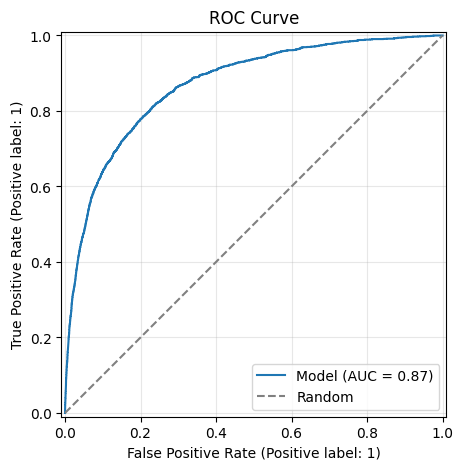

In [27]:
plot_roc_mpl(y_val, y_val_proba)

## 5.6

In [24]:
print(f"Training accuracy:   {pipeline.score(X_train, y_train):.4f}")
print(f"Validation accuracy: {pipeline.score(X_val,   y_val):.4f}")

Training accuracy:   0.7920
Validation accuracy: 0.7912
